In [1]:
!pip install kaggle


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kaggle]
   ---------------------------------------- 2/2 [kaggle]



### *Download Dataset load face mask at kaggle*

In [2]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown




  0%|          | 0.00/163M [00:00<?, ?B/s]
  1%|          | 1.00M/163M [00:03<08:09, 348kB/s]
  1%|1         | 2.00M/163M [00:06<08:56, 315kB/s]
  2%|1         | 3.00M/163M [00:08<07:37, 367kB/s]
  2%|2         | 4.00M/163M [00:11<07:01, 396kB/s]
  3%|3         | 5.00M/163M [00:14<07:41, 360kB/s]
  4%|3         | 6.00M/163M [00:16<07:03, 389kB/s]
  4%|4         | 7.00M/163M [00:19<07:09, 382kB/s]
  5%|4         | 8.00M/163M [00:21<06:36, 411kB/s]
  6%|5         | 9.00M/163M [00:23<06:09, 438kB/s]
  6%|6         | 10.0M/163M [00:27<06:41, 400kB/s]
  7%|6         | 11.0M/163M [00:29<06:52, 387kB/s]
  7%|7         | 12.0M/163M [00:33<07:21, 359kB/s]
  8%|7         | 13.0M/163M [00:37<08:23, 313kB/s]
  9%|8         | 14.0M/163M [00:42<09:23, 278kB/s]
  9%|9         | 15.0M/163M [00:47<10:09, 255kB/s]
 10%|9         | 16.0M/163M [00:48<08:11, 314kB/s]
 10%|#         | 17.0M/163M [00:50<07:00, 365kB/s]
 11%|#1        | 18.0M/163M [00:52<06:09, 412kB/s]
 12%|#1        | 19.0M/163M [00:54<05:

### *Dataset convert into Zip File*

In [2]:
import zipfile

with zipfile.ZipFile("face-mask-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")
    print("dataset upload completed")

dataset upload completed


In [15]:
pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 671.0 kB/s eta 0:01:00
    --------------------------------------- 0.5/40.2 MB 671.0 kB/s eta 0:01:00
    --------------------------------------- 0.8/40.2 MB 756.4 kB/s eta 0:00:53
   - -------------------------------------- 1.0/40.2 MB 807.3 kB/s eta 0:00:49
   - -------------------------------------- 1.3/40.2 MB 853.3 kB/s eta 0:00:46
   - -------------------------------------- 1.6/40.2 MB 905.4 kB/s eta 0:00:43
   - -------------------------------------- 1.8/40.2 MB 938.1 kB/s eta 0:00:41
   -- ------------------------------------- 2.1/40.2 MB 978.7 kB/s eta 0:00:39
   -- ------------

### *Import Libraries*

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

### *Data Preprocessing*

In [17]:
train_path = "dataset/"
img_size = 128
batch_size = 32
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)
train_data = datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)
val_data = datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 6043 images belonging to 1 classes.
Found 1510 images belonging to 1 classes.


### *Build CNN Model*

In [19]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### *Train Model*

In [20]:
history = model.fit(train_data,validation_data=val_data,epochs=10)

C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
 11/189 ━━━━━━━━━━━━━━━━━━━━ 50s 283ms/step - accuracy: 0.7684 - loss: 0.2113

C:\Users\Admin\anaconda3\Lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


189/189 ━━━━━━━━━━━━━━━━━━━━ 55s 277ms/step - accuracy: 0.9955 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 3.0386e-24
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 60s 319ms/step - accuracy: 1.0000 - loss: 5.5374e-14 - val_accuracy: 1.0000 - val_loss: 3.0386e-24
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 54s 286ms/step - accuracy: 1.0000 - loss: 2.1101e-19 - val_accuracy: 1.0000 - val_loss: 3.0386e-24
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 53s 280ms/step - accuracy: 1.0000 - loss: 1.4572e-13 - val_accuracy: 1.0000 - val_loss: 3.0386e-24
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 53s 278ms/step - accuracy: 1.0000 - loss: 6.5747e-18 - val_accuracy: 1.0000 - val_loss: 3.0386e-24
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 56s 298ms/step - accuracy: 1.0000 - loss: 1.8802e-13 - val_accuracy: 1.0000 - val_loss: 3.0385e-24
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 54s 283ms/step - accuracy: 1.0000 - loss: 3.9229e-18 - val_accuracy: 1.0000 - val_loss: 3.0385e-24
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 52

### *Plot Accuracy and loss*

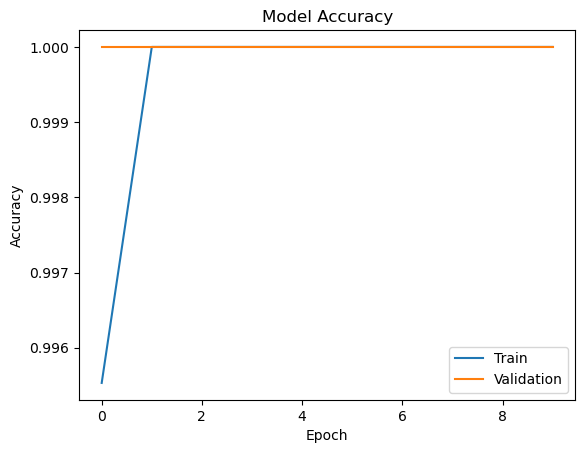

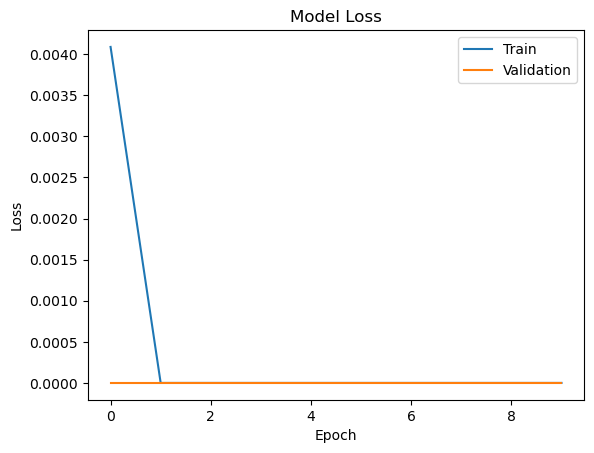

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

### *Test Single Image*

In [6]:
img_path = "with_mask_1.jpg"
img = cv2.imread(img_path)

if img is None:
    print("Error: Image not found. Check file path.")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)
    prediction = model.predict(img)
    print("Raw Prediction Value:", prediction[0][0])
    if prediction[0][0] > 0.5:
        print("Prediction: Without Mask")
    else:
        print("Prediction: With Mask")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
Raw Prediction Value: 0.47250056
Prediction: With Mask
